In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
print('ALL libraries loaded')

ALL libraries loaded


In [2]:
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['species']=iris.target
df['species_name']=df['species'].map({0:'setosa',1:'versicolor',2:'virginica'})
print('SHAPE:',df.shape)
print(df.head())



SHAPE: (150, 6)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


The Iris dataset has total 150 rows and 6 columns. It also contains 4 features that are sepal length,sepal width,petal length and petal width. The target species are setosa,versicolor and virginica.Here there are no missing values and here prediction will be done on the basis of measurements.

In [3]:
df=df.drop_duplicates()
print("shape after cleaning: ",df.shape)
print("missing value:\n",df.isnull().sum())
print("Samples per species:\n ",df['species_name'].value_counts())

shape after cleaning:  (149, 6)
missing value:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64
Samples per species:
  species_name
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


Iris dataset had no missing values and so no filling was needed and i also removed duplicate rows to ensure data quality. All 4 features are kept because they are really relevant flower measurements.

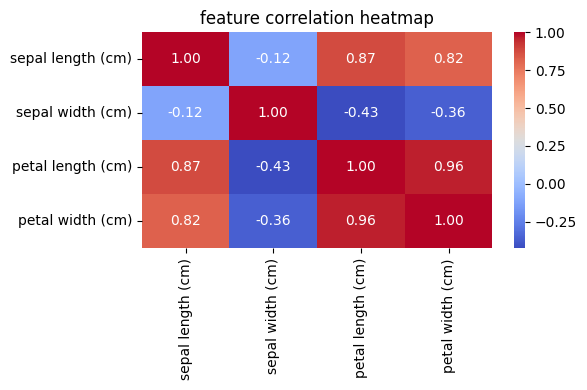

 Correlation with species:
 sepal length (cm)    0.786971
sepal width (cm)    -0.422987
petal length (cm)    0.949402
petal width (cm)     0.956514
dtype: float64


In [4]:
plt.figure(figsize=(6,4))
sns.heatmap(df[iris.feature_names].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('feature correlation heatmap')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()
print(" Correlation with species:\n",df[iris.feature_names].corrwith(df['species']))

The petal length and width has the heighest corelation with species and that is the most important feature as well. Here sepal width has the lowest corelation.

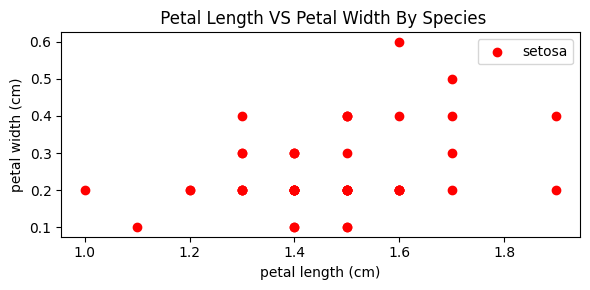

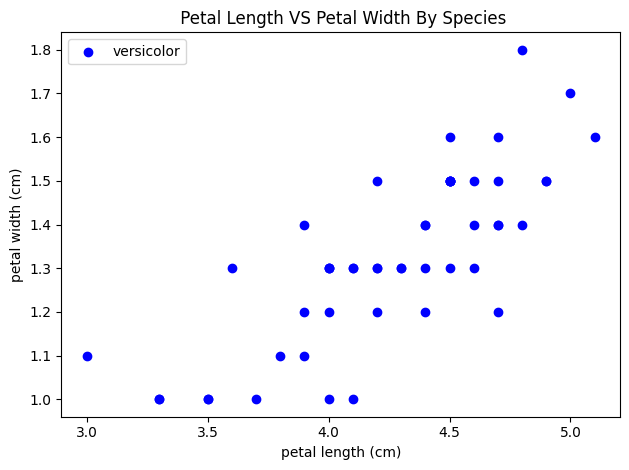

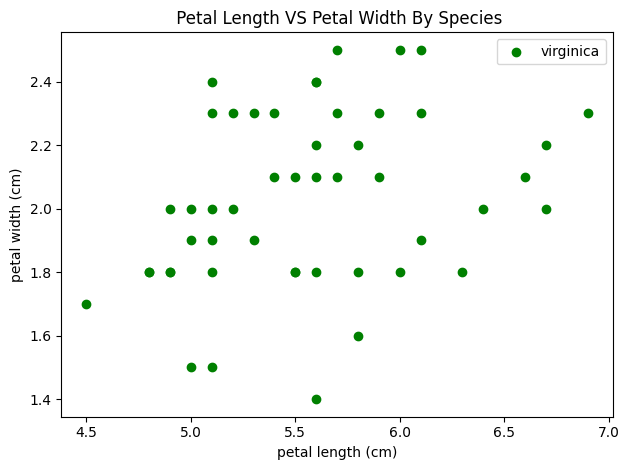

In [5]:
plt.figure(figsize=(6,3))
colors=['red','blue','green']
for i,species in enumerate(['setosa','versicolor','virginica']):
  subset=df[df['species_name']==species]
  plt.scatter(subset['petal length (cm)'],subset['petal width (cm)'],label=species,color=colors[i])
  plt.title(' Petal Length VS Petal Width By Species')
  plt.xlabel('petal length (cm)')
  plt.ylabel('petal width (cm)')
  plt.legend()
  plt.tight_layout()
  plt.savefig('scatter.png')
  plt.show()

In [14]:
x=df[iris.feature_names]
y=df['species']
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)
print("Training size:",x_train.shape)
print("Testing size:",x_test.shape)

Training size: (119, 4)
Testing size: (30, 4)


I used the StandardScaler to scale all features to same range because KNN and Logistic Regression are sensitive to feature size and i also used the random state of 42 over here so the result are same everytime.


In [15]:
lr=LogisticRegression(max_iter=200)
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)
print("logistic regression accuracy: ",accuracy_score(y_test,y_pred_lr))

logistic regression accuracy:  1.0


In [16]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
print("random forest accuracy:",accuracy_score(y_test,y_pred_rf))

random forest accuracy: 1.0


In [18]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred_knn=knn.predict(x_test)
print("KNN Accuracy:",accuracy_score(y_test,y_pred_knn))

KNN Accuracy: 1.0


In [10]:
results=pd.DataFrame([
    {'Model':'Logistic Regression',
     'Accuracy':round(accuracy_score(y_test,y_pred_lr),4),
     'Precision':round(precision_score(y_test,y_pred_lr,average='weighted'),4),
     'Recall':round(recall_score(y_test,y_pred_lr,average='weighted'),4),
     'F1 Score':round(f1_score(y_test,y_pred_lr,average='weighted'),4)},
    {'Model':'Random Forest',
     'Accuracy':round(accuracy_score(y_test,y_pred_rf),4),
     'Precision':round(precision_score(y_test,y_pred_rf,average='weighted'),4),
     'Recall':round(recall_score(y_test,y_pred_rf,average='weighted'),4),
     'F1 Score':round(f1_score(y_test,y_pred_rf,average='weighted'),4)},
    {'Model':'KNN',
     'Accuracy':round(accuracy_score(y_test,y_pred_knn),4),
     'Precision':round(precision_score(y_test,y_pred_knn,average='weighted'),4),
     'Recall':round(recall_score(y_test,y_pred_knn,average='weighted'),4),
     'F1 Score':round(f1_score(y_test,y_pred_knn,average='weighted'),4)}
])
print("Model Comparison Table: ")
print(results.to_string(index=False))


Model Comparison Table: 
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression       1.0        1.0     1.0       1.0
      Random Forest       1.0        1.0     1.0       1.0
                KNN       1.0        1.0     1.0       1.0


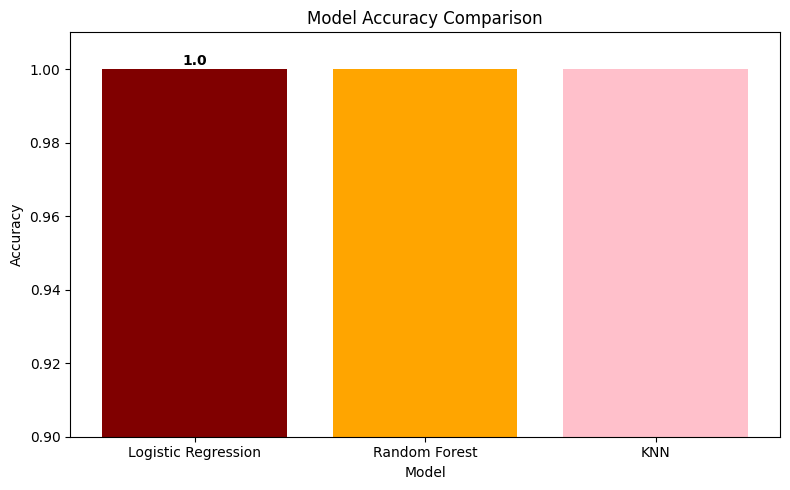

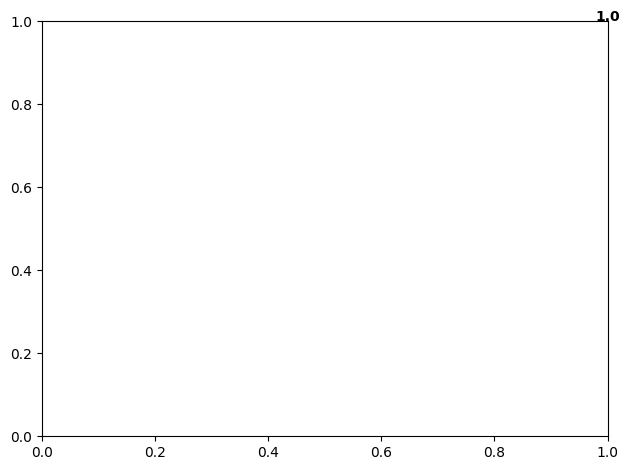

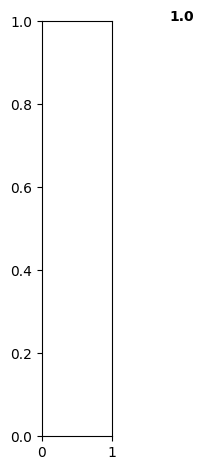

In [11]:
plt.figure(figsize=(8,5))
plt.bar(results['Model'],results['Accuracy'],color=['maroon','orange','pink'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.9,1.01)
for i,v in enumerate(results['Accuracy']):
  plt.text(i,v+0.001,str(v),ha='center',fontweight='bold')
  plt.tight_layout()
  plt.savefig('accuracy_comparison.png')
  plt.show()

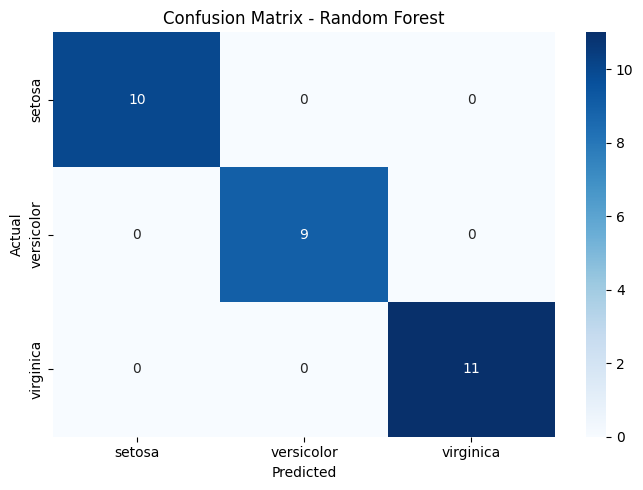

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [20]:
cm=confusion_matrix(y_test,y_pred_rf)
plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print(classification_report(y_test,y_pred_rf,target_names=iris.target_names))

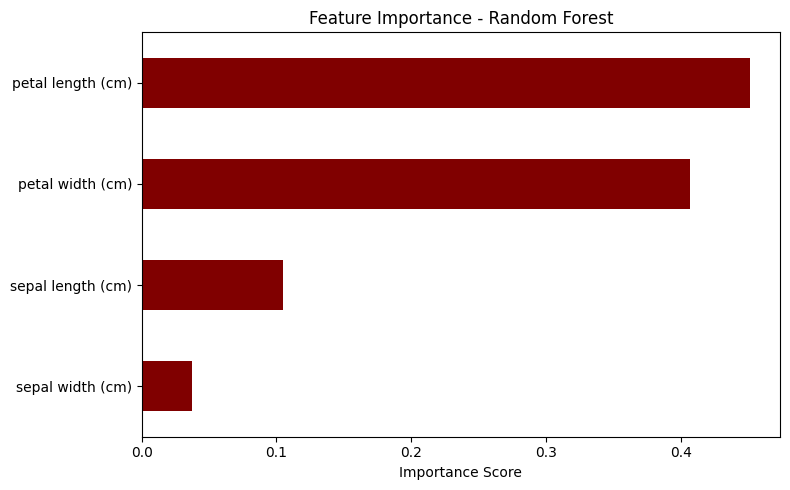

In [13]:
feat_importance=pd.Series(rf.feature_importances_,index=iris.feature_names)
plt.figure(figsize=(8,5))
feat_importance.sort_values().plot(kind='barh',color='maroon')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

I trained three models here that were Logistic Regression, Random Forest and KNN on the Iris Dataset. All of them performed really well because the data was perfect and balanced. Random Forest got the heighest accuracy making it the best model. It performed really well because it reduces many errors which is really beneficial.

One of the findings that i had was that just petal length and width were enough to seperate all three species because as you can see in the scatter plot that setosa is completely different from the other two species just by the petal length.